In [1]:
from fingerprint import AudioFingerprinter
import matplotlib.pyplot as plt
import numpy as np
import librosa.display




In [2]:
fp = AudioFingerprinter()
y, sr = fp.preprocess("songs/Neelothi.mp3")
t = np.linspace(0, len(y)/sr, num=len(y))

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


Length (seconds): 6051328
Sample Rate: 22050
Max amplitude: 0.9980209
Min amplitude: -0.9986617


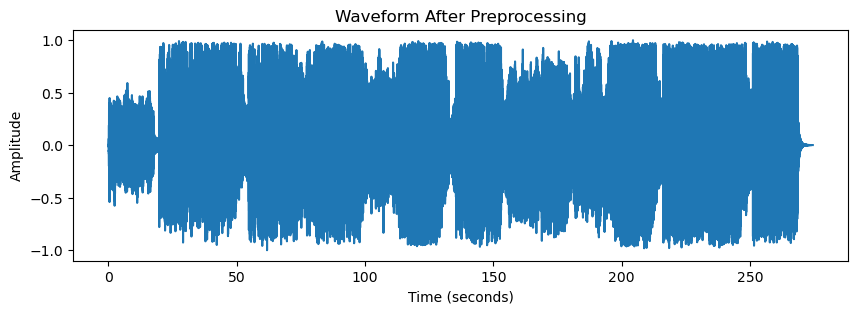

In [3]:
print("Length (seconds):", len(t))
print("Sample Rate:", sr)
print("Max amplitude:", y.max())
print("Min amplitude:", y.min())


plt.figure(figsize=(10, 3))
plt.plot(t, y)
plt.title("Waveform After Preprocessing")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


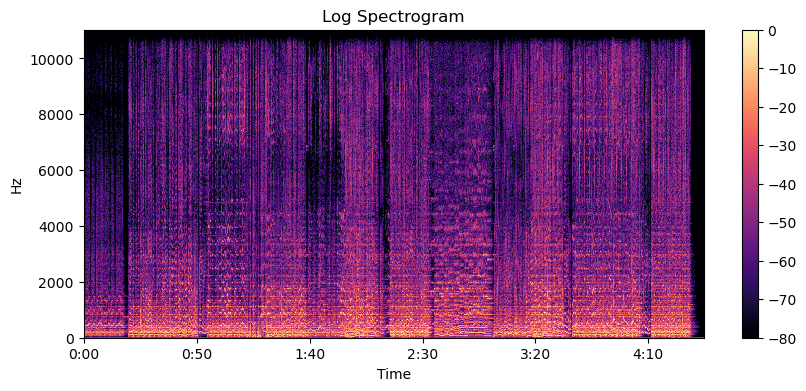

In [4]:
S_db = fp.generate_spectrogram(y)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=fp.hop_length,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar()
plt.title("Log Spectrogram")
plt.show()

In [5]:
peaks = fp.find_peaks(S_db)
print("Peaks (time_idx, freq_idx):", peaks)

print("Number of peaks:", len(peaks))

Peaks (time_idx, freq_idx): [(np.int64(0), np.int64(2231)), (np.int64(0), np.int64(10683)), (np.int64(4), np.int64(3113)), (np.int64(4), np.int64(3218)), (np.int64(4), np.int64(3312)), (np.int64(4), np.int64(3417)), (np.int64(4), np.int64(3440)), (np.int64(4), np.int64(3453)), (np.int64(4), np.int64(3488)), (np.int64(4), np.int64(3558)), (np.int64(4), np.int64(3641)), (np.int64(4), np.int64(3689)), (np.int64(4), np.int64(3724)), (np.int64(4), np.int64(3829)), (np.int64(4), np.int64(6645)), (np.int64(4), np.int64(6661)), (np.int64(5), np.int64(856)), (np.int64(5), np.int64(2524)), (np.int64(5), np.int64(3264)), (np.int64(5), np.int64(3393)), (np.int64(5), np.int64(3840)), (np.int64(5), np.int64(4215)), (np.int64(5), np.int64(5010)), (np.int64(5), np.int64(5071)), (np.int64(5), np.int64(5088)), (np.int64(5), np.int64(5104)), (np.int64(5), np.int64(5124)), (np.int64(5), np.int64(5156)), (np.int64(5), np.int64(5573)), (np.int64(5), np.int64(5611)), (np.int64(5), np.int64(8561)), (np.int64(

In [6]:
hashes = fp.generate_hashes(peaks)
print("Sample hashes (hash_value, time_offset):", hashes[:10])

Sample hashes (hash_value, time_offset): [(np.int64(8162911763824640), np.int64(12)), (np.int64(8162808684675072), np.int64(12)), (np.int64(8162843044413440), np.int64(12)), (np.int64(8162877404217344), np.int64(12)), (np.int64(8162778620035072), np.int64(12)), (np.int64(8162795800166400), np.int64(12)), (np.int64(8162843045396480), np.int64(12)), (np.int64(9007233614544896), np.int64(16)), (np.int64(9007267974283264), np.int64(16)), (np.int64(9007302334087168), np.int64(16))]
